In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
demand = pd.read_csv("demand_forecast_summary.csv")

In [3]:
#  Business assumptions
LEAD_TIME_DAYS = 3       # days between placing and receiving an order
SERVICE_LEVEL = 0.95     # probability of NOT stocking out (95% target)
UNIT_COST = 5.0          # ₹ cost per unit (assumption, stated clearly)
HOLDING_COST_RATE = 0.20  # 20% of unit cost per year to hold 1 unit in stock

z = norm.ppf(SERVICE_LEVEL)  # z-score for the chosen service level

In [4]:
# Reorder point & safety stock formulas
# Safety stock   = z * std_daily_demand * sqrt(lead_time)
# Reorder point  = (avg_daily_demand * lead_time) + safety_stock

demand["safety_stock"] = z * demand["std_daily_demand"] * np.sqrt(LEAD_TIME_DAYS)
demand["reorder_point"] = (
    demand["avg_daily_demand"] * LEAD_TIME_DAYS + demand["safety_stock"]
)
demand["annual_holding_cost"] = (
    demand["safety_stock"] * UNIT_COST * HOLDING_COST_RATE
)

demand.to_csv("inventory_policy.csv", index=False)
print("Saved inventory_policy.csv")
print(demand.head())

print(f"\nTotal annual safety-stock holding cost across all store-items: "
      f"₹{demand['annual_holding_cost'].sum():,.0f}")

Saved inventory_policy.csv
   store  item  avg_daily_demand  std_daily_demand  safety_stock  \
0      1     1         22.493453          5.231010     14.902989   
1      1     2         59.955269         14.157695     40.334850   
2      1     3         37.683349          8.844934     25.198953   
3      1     4         22.444548          5.118532     14.582545   
4      1     5         19.182469          4.139651     11.793740   

   reorder_point  annual_holding_cost  
0      82.383348            14.902989  
1     220.200659            40.334850  
2     138.249001            25.198953  
3      81.916189            14.582545  
4      69.341149            11.793740  

Total annual safety-stock holding cost across all store-items: ₹18,668



Saved cost_vs_service_level.png — this is your headline chart

Interpretation: holding cost rises sharply as service level
approaches 99% — classic diminishing returns. This is the
chart to lead with when presenting a recommendation.


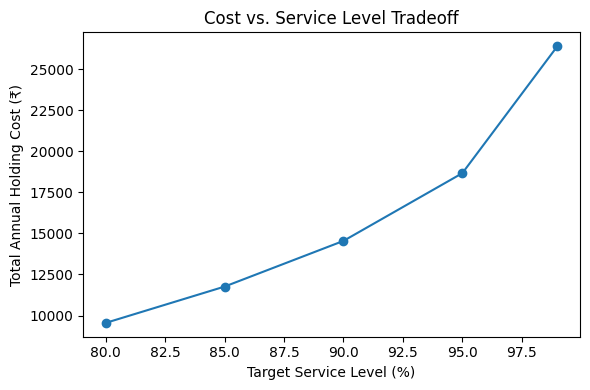

In [5]:
# Service level vs. cost tradeoff

service_levels = [0.80, 0.85, 0.90, 0.95, 0.99]
total_costs = []

for sl in service_levels:
    z_sl = norm.ppf(sl)
    ss = z_sl * demand["std_daily_demand"] * np.sqrt(LEAD_TIME_DAYS)
    cost = (ss * UNIT_COST * HOLDING_COST_RATE).sum()
    total_costs.append(cost)

plt.figure(figsize=(6, 4))
plt.plot([sl * 100 for sl in service_levels], total_costs, marker="o")
plt.xlabel("Target Service Level (%)")
plt.ylabel("Total Annual Holding Cost (₹)")
plt.title("Cost vs. Service Level Tradeoff")
plt.tight_layout()
plt.savefig("cost_vs_service_level.png")
print("\nSaved cost_vs_service_level.png — this is your headline chart")
print("\nInterpretation: holding cost rises sharply as service level")
print("approaches 99% — classic diminishing returns. This is the")
print("chart to lead with when presenting a recommendation.")
